# Uncertainty quantification for differential cross sections using KDUQ

KDUQ is an uncertainty quantified global optical potential (see [Pruitt et al., 2023](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.107.014602)).

It is one of the potentials built into `jitr`. We will see how to use it for propagating uncertainties in this demo.

In [1]:
# import stuff for nice plotting
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import jitr

In [2]:
from jitr.optical_potentials import kduq

In [3]:
#  elastic reaction
target = (54, 26)
proton = (1, 1)
neutron = (1, 0)
projectile = proton

reaction = jitr.reactions.ElasticReaction(
    target=target,
    projectile=projectile,
)

# energy
Elab = 35
kinematics = reaction.kinematics(Elab)

# for plotting differential xs
angles = np.linspace(0.1, np.pi, 180)

# Lagrange Mesh
core_solver = jitr.rmatrix.Solver(40)

# set up our solver to calculate differential cross sections

In [4]:
# get kinematics and parameters for this experiment

a = jitr.utils.interaction_range(target[0]) * kinematics.k + np.pi * 2
N = jitr.utils.suggested_basis_size(a)
assert N < core_solver.kernel.quadrature.nbasis
channel_radius_fm = a / kinematics.k

# build solver
solver = jitr.xs.elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius_fm,
    solver=core_solver,
    lmax=50,
    angles=angles,
)

# grab kduq posterior samples 

In [5]:
help(kduq.get_samples)

Help on function get_samples in module jitr.optical_potentials.kduq:

get_samples(projectile: tuple[int, int], posterior: str = 'federal') -> numpy.ndarray
    Get the posterior samples for the given projectile (neutron or
    proton) from the KDUQ Federal or Democratic posteriors.

    See [Pruitt, et al., 2023]
    (https://journals.aps.org/prc/pdf/10.1103/PhysRevC.107.014602) for
    details on the KDUQ posteriors.

    :param projectile: tuple A tuple representing the projectile, with format (Ap,
                       Zp), where Ap is the mass number and Zp is the atomic number.
                       Must be either (1, 0) for neutron or (1, 1) for proton.
    :param posterior: str Which KDUQ posterior to return samples from. Must be
                      either "federal" or "democratic". Defaults to "federal".
    :returns: An array of shape (NUM_POSTERIOR_SAMPLES, num_params) containing the
              posterior samples for the given projectile, where num_params is the
       

In [6]:
kduq_samples = kduq.get_samples(projectile)

## Set up the potential

Let's take a look at the functionality built into jitr:

In [7]:
omp = kduq.KDUQ(projectile)
help(omp)

Help on KDUQ in module jitr.optical_potentials.kduq object:

class KDUQ(jitr.optical_potentials.omp.SingleChannelOpticalModel)
 |  KDUQ(projectile: tuple)
 |
 |  Koning-Delaroche Uncertainty Quantification (KDUQ) optical
 |  potential model.
 |
 |  Method resolution order:
 |      KDUQ
 |      jitr.optical_potentials.omp.SingleChannelOpticalModel
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, projectile: tuple)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  evaluate(self, rgrid: float | numpy.ndarray, reaction: jitr.reactions.reaction.Reaction, kinematics: jitr.utils.kinematics.ChannelKinematics, *params: float) -> tuple[complex | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.complex128]], complex | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.complex128]], float | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.float64]]]
 |      Evaluate the KDUQ central, spin-orbit, and Coulomb terms.
 |
 |  ----

In [8]:
help(jitr.optical_potentials.kduq.central)

Help on function central in module jitr.optical_potentials.kduq:

central(r: float | numpy.ndarray, Vv: float, Rv: float, av: float, Wv: float, Rwv: float, awv: float, Wd: float, Rd: float, ad: float) -> complex | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.complex128]]
    Koning-Delaroche central terms at a given energy.

    This matches Eq. (7) in Koning and Delaroche (2003).

    :param r: float or np.ndarray The radius at which to evaluate the potential.
    :param Vv: float The real central depth.
    :param Rv: float The real central radius parameter.
    :param av: float The real central diffuseness parameter.
    :param Wv: float The imaginary volume depth.
    :param Rwv: float The imaginary volume radius parameter.
    :param awv: float The imaginary volume diffuseness parameter.
    :param Wd: float The imaginary surface depth.
    :param Rd: float The imaginary surface radius parameter.
    :param ad: float The imaginary surface diffuseness parameter.



In [9]:
help(jitr.optical_potentials.kduq.spin_orbit)

Help on function spin_orbit in module jitr.optical_potentials.kduq:

spin_orbit(r: float | numpy.ndarray, Vso: float, Rso: float, aso: float, Wso: float, Rwso: float, awso: float) -> complex | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.complex128]]
    Koning-Delaroche spin-orbit terms at a given energy.

    This matches Eq. (7) in Koning and Delaroche (2003).

    :param r: float or np.ndarray The radius at which to evaluate the potential.
    :param Vso: float The real spin-orbit depth.
    :param Rso: float The real spin-orbit radius parameter.
    :param aso: float The real spin-orbit diffuseness parameter.
    :param Wso: float The imaginary spin-orbit depth.
    :param Rwso: float The imaginary spin-orbit radius parameter.
    :param awso: float The imaginary spin-orbit diffuseness parameter.



In [10]:
help(jitr.optical_potentials.potential_forms.coulomb_charged_sphere)

Help on function coulomb_charged_sphere in module jitr.optical_potentials.potential_forms:

coulomb_charged_sphere(r: 'ArrayOrScalar', zz: 'float', r_c: 'float') -> 'ArrayOrScalar'
    Return the Coulomb potential of a uniformly charged sphere.



# run calculation

This should demonstrate how the `KDUQ` class (`omp`) is built to interface with `solver`, which is an instance of `jitr.xs.elastic.DifferentialWorkspace`. This is how calculations are done in jitr.

In [11]:
kduq_xs = np.zeros((len(angles), kduq.NUM_POSTERIOR_SAMPLES))
rgrid = solver.radial_grid()

for j, sample in enumerate(tqdm(kduq_samples)):
    central_term, spin_orbit_term, coulomb_term = omp(
        rgrid, reaction, kinematics, *sample
    )
    xs = solver.xs(central_term, spin_orbit_term, coulomb_term)
    kduq_xs[:, j] = xs.dsdo / solver.rutherford

 95%|██████████████████████████████████████████████████████████████████████████▍   | 397/416 [00:11<00:00, 229.31it/s]/home/kyle/umich/jitr/src/jitr/optical_potentials/kduq.py:467: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))
100%|███████████████████████████████████████████████████████████████████████████████| 416/416 [00:11<00:00, 36.63it/s]


# calculate CIs and plot

In [12]:
kduq_pred_post = np.percentile(kduq_xs, [16, 84], axis=1)

Text(0, 0.5, '$\\frac{d \\sigma}{d\\Omega} / \\frac{d \\sigma_{R}}{d\\Omega} $')

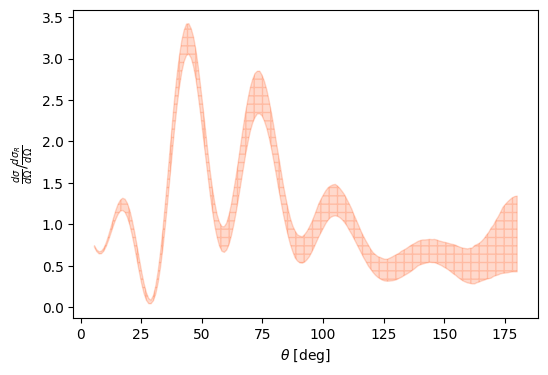

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.fill_between(
    angles * 180 / np.pi,
    kduq_pred_post[0],  # / solver.rutherford,
    kduq_pred_post[1],  # / solver.rutherford,
    color="#ff4500",
    hatch="|-|-",
    alpha=0.2,
)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\frac{d \sigma}{d\Omega} / \frac{d \sigma_{R}}{d\Omega} $")

In [14]:
# NBVAL_CHECK_OUTPUT
print(f"{kduq_pred_post[1][9]:1.6f}")

1.163423


In fact, `KDUQ` is just one definition of a global optical potential. `jitr` also has others built in:

In [15]:
help(jitr.optical_potentials.wlh.WLH)

Help on class WLH in module jitr.optical_potentials.wlh:

class WLH(jitr.optical_potentials.omp.SingleChannelOpticalModel)
 |  WLH(projectile: tuple)
 |
 |  The Whitehead-Lim-Holt global optical potential for nucleon-nucleus
 |  scattering.
 |
 |  Method resolution order:
 |      WLH
 |      jitr.optical_potentials.omp.SingleChannelOpticalModel
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, projectile: tuple)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  evaluate(self, rgrid: float | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.float64]], reaction: jitr.reactions.reaction.Reaction, kinematics: jitr.utils.kinematics.ChannelKinematics, *params: float) -> tuple[complex | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.complex128]], complex | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.complex128]], float | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.float64]]]
 |      Evaluate the centra

In [16]:
help(jitr.optical_potentials.chuq.CHUQ)

Help on class CHUQ in module jitr.optical_potentials.chuq:

class CHUQ(jitr.optical_potentials.omp.SingleChannelOpticalModel)
 |  Chapel-Hill Uncertainty Quantification (CHUQ) optical
 |  potential model.
 |
 |  Note that CH89 is Lane consistent, so the same parameters can be
 |  used for both neutron and proton projectiles.
 |
 |  Method resolution order:
 |      CHUQ
 |      jitr.optical_potentials.omp.SingleChannelOpticalModel
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  evaluate(self, rgrid: float | numpy.ndarray, reaction: jitr.reactions.reaction.Reaction, kinematics: jitr.utils.kinematics.ChannelKinematics, *params: float) -> tuple[complex | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.complex128]], complex | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.complex128]], float | numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[numpy.float64]]]
 |      Eva

In fact, these are all derived from `jitr.optical_potentials.SingleChannelOpticalModel`, which sets the interface between the model for the effective interaction and the solver. You can come up with your own optical model and derive your own class from `jitr.optical_potentials.SingleChannelOpticalModel` to plug it into jitr!

In [17]:
help(jitr.optical_potentials.SingleChannelOpticalModel)

Help on class SingleChannelOpticalModel in module jitr.optical_potentials.omp:

class SingleChannelOpticalModel(builtins.object)
 |  SingleChannelOpticalModel(params: 'list[str]') -> 'None'
 |
 |  Base class for local single-channel optical potentials.
 |
 |  Methods defined here:
 |
 |  __call__(self, rgrid: 'ArrayOrScalar', reaction: 'reaction.Reaction', kinematics: 'kinematics.ChannelKinematics', *params: 'float') -> 'tuple[PotentialArray, PotentialArray, PotentialArray | ArrayOrScalar]'
 |      Call self as a function.
 |
 |  __init__(self, params: 'list[str]') -> 'None'
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  evaluate(self, rgrid: 'ArrayOrScalar', reaction: 'reaction.Reaction', kinematics: 'kinematics.ChannelKinematics', *params: 'float') -> 'tuple[PotentialArray, PotentialArray, PotentialArray | ArrayOrScalar]'
 |      Evaluate central, spin-orbit, and Coulomb terms on ``rgrid``.
 |
 |  --------------------------------------------------------